In [1]:
import pandas as pd
import numpy as np

from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import TimeSeriesSplit, RandomizedSearchCV
from sklearn.preprocessing import StandardScaler

df = pd.read_csv(r'C:\DATA ANALYSIS AND DATA SCIENCE PROJECTS\Multi Scale Energy Stress Analysis\data\forecasting_feature_set.csv')

# DEFINE TARGET (t+1 prediction)
# Shift target to future
df['target'] = df['net_load_mw'].shift(-1)
df = df.dropna().reset_index(drop=True)

split_index = int(len(df) * 0.8)

train_df = df.iloc[:split_index]
test_df  = df.iloc[split_index:]

X_train = train_df.drop(columns=['target'])
y_train = train_df['target']

X_test = test_df.drop(columns=['target'])
y_test = test_df['target']

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

rf = RandomForestRegressor(random_state=42, n_jobs=-1)

param_dist = {
    'n_estimators': [100, 200, 300, 500],
    'max_depth': [10, 20, 30, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2']
}

tscv = TimeSeriesSplit(n_splits=5)

random_search = RandomizedSearchCV(
    estimator=rf,
    param_distributions=param_dist,
    n_iter=20,
    cv=tscv,
    scoring='neg_root_mean_squared_error',
    verbose=2,
    random_state=42,
    n_jobs=-1
)

random_search.fit(X_train_scaled, y_train)
best_model = random_search.best_estimator_
print("Best Parameters:")
print(random_search.best_params_)

y_pred = best_model.predict(X_test_scaled)

Fitting 5 folds for each of 20 candidates, totalling 100 fits
Best Parameters:
{'n_estimators': 200, 'min_samples_split': 2, 'min_samples_leaf': 2, 'max_features': 'sqrt', 'max_depth': 30}


In [2]:
#MODEL EVALUATION
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.metrics import r2_score

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae  = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
epsilon = 1e-6
mape = np.mean(np.abs((y_test - y_pred) / (y_test + epsilon))) * 100

print("RANDOM FOREST PERFORMANCE METRICS")
print(f"RMSE : {rmse:.4f}")
print(f"MAE  : {mae:.4f}")
print(f"R²   : {r2:.4f}")
print(f"MAPE : {mape:.2f}%")

errors = y_test - y_pred
print("\nError Summary:")
print(f"Mean Error      : {np.mean(errors):.4f}")
print(f"Std Error       : {np.std(errors):.4f}")
print(f"Max Error       : {np.max(np.abs(errors)):.4f}")

RANDOM FOREST PERFORMANCE METRICS
RMSE : 273.8949
MAE  : 185.4865
R²   : 0.9981
MAPE : 1.08%

Error Summary:
Mean Error      : 3.4816
Std Error       : 273.8728
Max Error       : 3439.0505


TOP 10 IMPORTANT FEATURES
net_load_mw                    0.272140
net_load_lag_24h               0.115026
total_renewable_penetration    0.113606
net_load_lag_1h                0.107051
demand_avg_mw                  0.060850
solar_penetration              0.057956
low_ren_high_dem               0.046191
demand_percentile_rank         0.043342
demand_lag_1h                  0.038023
solar_gen_mw                   0.029738
dtype: float64


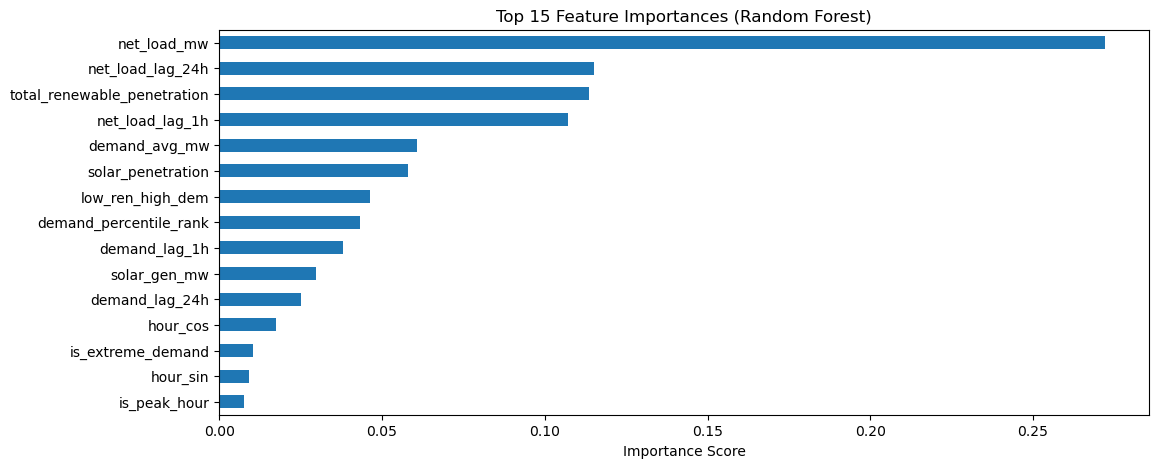

In [3]:
# FEATURE IMPORTANCE
import matplotlib.pyplot as plt

importances = pd.Series(best_model.feature_importances_, index=X_train.columns)
importances = importances.sort_values(ascending=False)

print("TOP 10 IMPORTANT FEATURES")
print(importances.head(10))

top_n = 15
top_features = importances.head(top_n)

plt.figure(figsize=(12, 5))
top_features.sort_values().plot(kind='barh')
plt.title(f"Top {top_n} Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.show()

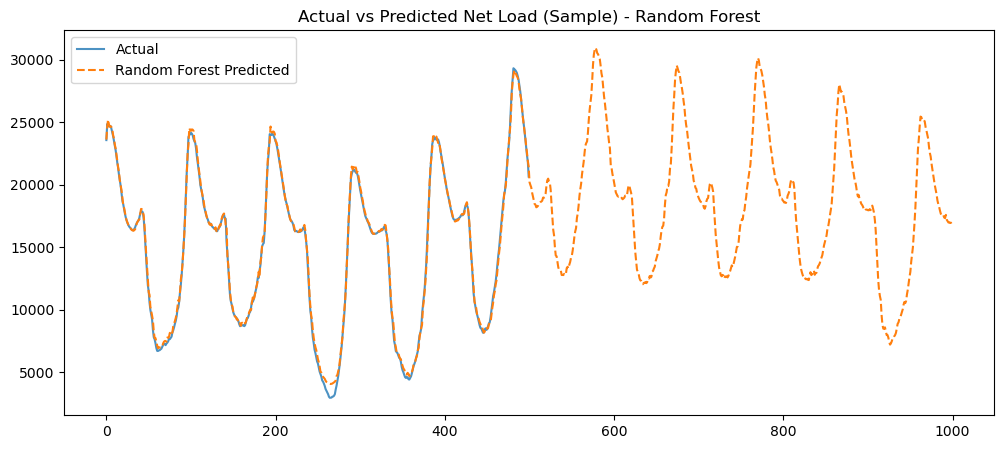

In [7]:
plt.figure(figsize=(12, 5))
plt.plot(y_test.values[:500], label="Actual", alpha = 0.8)
plt.plot(y_pred[:1000], label="Random Forest Predicted", linestyle = '--')
plt.title("Actual vs Predicted Net Load (Sample) - Random Forest")
plt.legend()
plt.show()

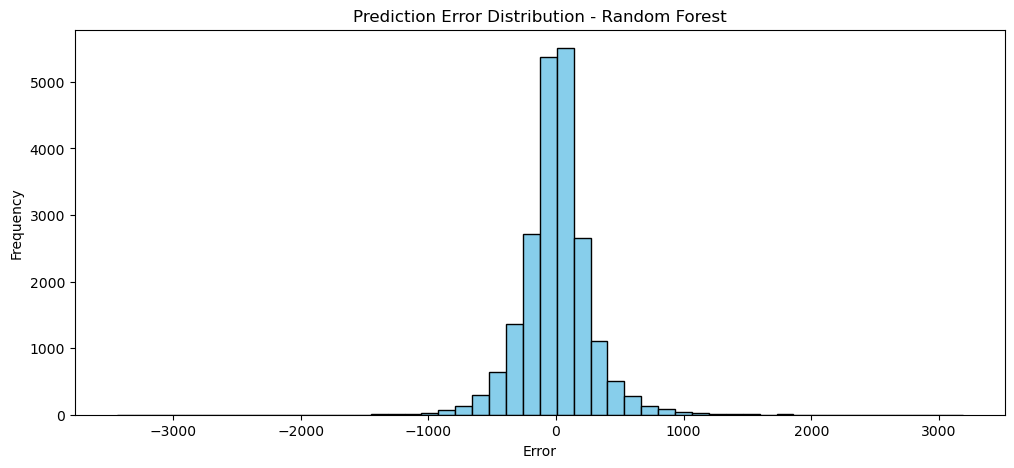

In [5]:
plt.figure(figsize=(12, 5))
plt.hist(errors, bins=50, color = 'skyblue', edgecolor = 'black')
plt.title("Prediction Error Distribution - Random Forest")
plt.xlabel("Error")
plt.ylabel("Frequency")
plt.show()

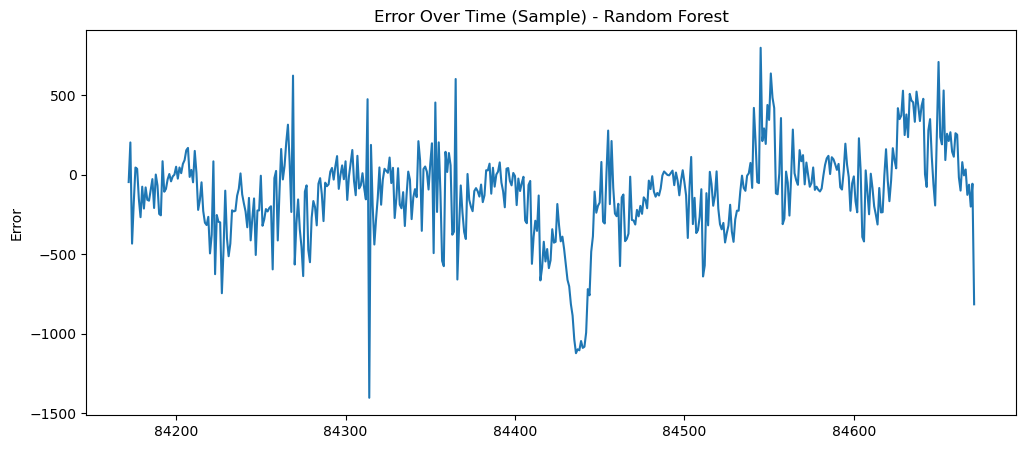

In [ ]:
plt.figure(figsize=(12, 5))
plt.plot(errors[:1000])
plt.title("Error Over Time (Sample) - Random Forest")
plt.ylabel("Error")
plt.show()